In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from time import perf_counter
from wordcloud import WordCloud, STOPWORDS
import sys, email, string
from nltk.stem import WordNetLemmatizer
import nltk
import os, gc, re
from IPython.display import Markdown, display
def printmd(string):
    # Print with Markdowns    
    display(Markdown(string))

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import pickle as pkl
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

from tqdm import tqdm
tqdm.pandas()

In [2]:
print(os.getcwd())

d:\Projects\ML\Phishing-Detection-AI-Techniques\old


In [3]:
df = pd.read_csv('dataset\spam_ham_dataset.csv')
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  5171 non-null   int64 
 1   label       5171 non-null   object
 2   text        5171 non-null   object
 3   label_num   5171 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 161.7+ KB


In [5]:
df.drop('Unnamed: 0', axis=1, inplace = True)

In [6]:
print("==== Null values count ====")
print(df.isnull().sum())

print("\n==== Duplicate values count ====")
print(df.duplicated().sum())

print("\n===== Unique values count =====")
print(df.nunique())

==== Null values count ====
label        0
text         0
label_num    0
dtype: int64

==== Duplicate values count ====
178

===== Unique values count =====
label           2
text         4993
label_num       2
dtype: int64


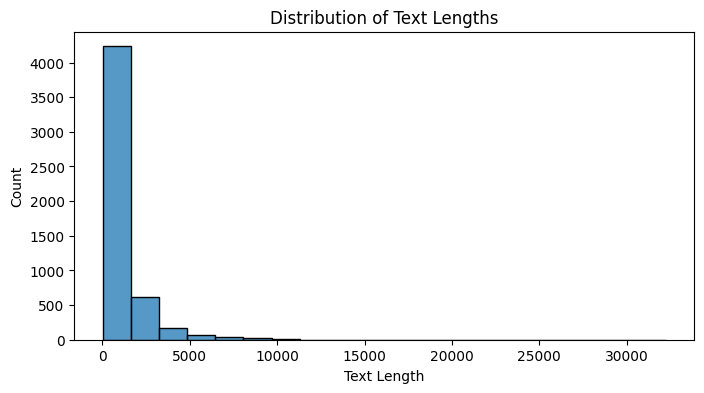

In [7]:
df['length'] = df['text'].str.len()

plt.figure(figsize=(8,4))
sns.histplot(df['length'], bins=20)
plt.title('Distribution of Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Count')
plt.show()


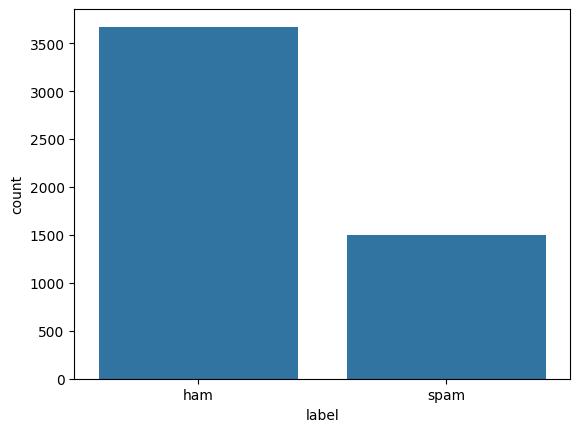

In [8]:
sns.countplot(data=df, x='label')
plt.show()

In [9]:
from nltk.tokenize import RegexpTokenizer

def clean_str(string, reg = RegexpTokenizer(r'[a-z]+')):
    string = string.lower()
    tokens = reg.tokenize(string)
    return " ".join(tokens)

df['text'] = df['text'].progress_apply(lambda string: clean_str(string))

100%|██████████| 5171/5171 [00:00<00:00, 28895.79it/s]


In [10]:
def rem_sub(i):
    return i.replace('subject', '')
df['text'] = df['text'].map(rem_sub)

In [11]:
x = df['text']
Y = df.label_num

print(x[0])
print(x.shape)

 enron methanol meter this is a follow up to the note i gave you on monday preliminary flow data provided by daren please override pop s daily volume presently zero to reflect daily activity you can obtain from gas control this change is needed asap for economics purposes
(5171,)


In [12]:
spam=[]
ham=[]
def split():
    for i in range(0,len(x)):
        if(df['label_num'][i]==0):
            ham.append(x[i])
        else:
            spam.append(x[i])
split()
print(ham[0])

 enron methanol meter this is a follow up to the note i gave you on monday preliminary flow data provided by daren please override pop s daily volume presently zero to reflect daily activity you can obtain from gas control this change is needed asap for economics purposes


Short Text Classification: A Survey


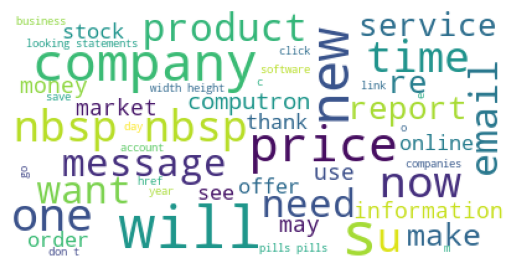

In [13]:
#WordCloud for spam

stopwords = set(STOPWORDS)
print('Short Text Classification: A Survey')
#print(Counter(word_count(str(spam))).most_common(100))
for i in range (0,len(x)):
    text=' '.join(spam)
    
cloud = WordCloud(
    max_font_size=50,
    background_color='white',
    max_words=50
    ).generate(text)
fig = plt.figure(1)
plt.imshow(cloud)
plt.axis('off')
plt.show()
fig.savefig("dataset\Short_Text_Classification_Spam")

Short Text Classification: A Survey


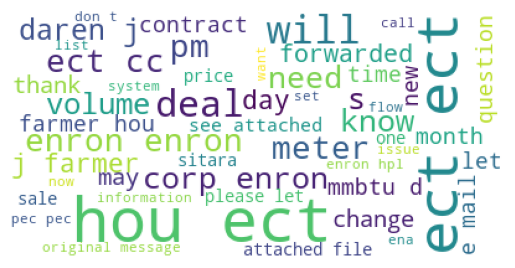

In [14]:
#WordCloud for ham

stopwords = set(STOPWORDS)
print('Short Text Classification: A Survey')
#print(Counter(word_count(str(spam))).most_common(100))
for i in range (0,len(x)):
    text1=' '.join(ham)
    
cloud = WordCloud(
    max_font_size=50,
    background_color='white',
    max_words=50
    ).generate(text1)
fig = plt.figure(1)
plt.imshow(cloud)
plt.axis('off')
plt.show()
fig.savefig("dataset\Short_Text_Classification_Ham")

In [15]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
x = cv.fit_transform(x)

# Get the categories
y = df.label

In [16]:
pkl.dump(cv, open("models/vectorizer.pkl", "wb"))
print(x[0])

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 40 stored elements and shape (1, 45740)>
  Coords	Values
  (0, 14014)	1
  (0, 26332)	1
  (0, 26325)	1
  (0, 40282)	2
  (0, 21666)	2
  (0, 16145)	1
  (0, 42124)	1
  (0, 40663)	2
  (0, 40160)	1
  (0, 28511)	1
  (0, 17060)	1
  (0, 45238)	2
  (0, 29224)	1
  (0, 27019)	1
  (0, 31984)	1
  (0, 16034)	1
  (0, 10583)	1
  (0, 32527)	1
  (0, 6061)	1
  (0, 10526)	1
  (0, 31355)	1
  (0, 29788)	1
  (0, 31615)	1
  (0, 10428)	2
  (0, 43171)	1
  (0, 32049)	1
  (0, 45469)	1
  (0, 33952)	1
  (0, 439)	1
  (0, 6337)	1
  (0, 28852)	1
  (0, 16582)	1
  (0, 17005)	1
  (0, 9237)	1
  (0, 7206)	1
  (0, 27917)	1
  (0, 2542)	1
  (0, 16206)	1
  (0, 13193)	1
  (0, 32771)	1
